1. Data
2. Training Data
3. Testing Data

Notebook
    - Image Classifier

lib 
    tensorflow,pandas,matplotlib,seaborn,numpy

In [ ]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

Download and Extract Flower Dataset

In [10]:
import pathlib

# Download the flower dataset from TensorFlow
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

dataset_path = tf.keras.utils.get_file(
    fname="flower_photos",
    origin=dataset_url,
    untar=True
)

# Convert the dataset path into a Path object
dataset_path = pathlib.Path(dataset_path)

# Move into the inner flower_photos folder
dataset_path = dataset_path / "flower_photos"

# The dataset_path from get_file already points to the root directory containing the flower classes.
# No further appending of 'flower_photos' is needed.
print(f"Dataset location:{dataset_path}")

Dataset location:C:\Users\gauta\.keras\datasets\flower_photos\flower_photos


### Data Overview 
    

In [12]:
# Get all the flower folder names
flowers = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])

# Show what flowers we're working with
print("=== Flower Types ===")
for f in flowers:
    print(f"- {f}")

# Count everything
total = len(list(dataset_path.glob("*/*.jpg")))
print(f"\nTotal photos: {total}")

# Count per flower type
print("\n=== Photos by Type ===")
for f in flowers:
    count = len(list((dataset_path / f).glob("*.jpg")))
    print(f"{f}: {count}")

=== Flower Types ===
- daisy
- dandelion
- roses
- sunflowers
- tulips

Total photos: 3670

=== Photos by Type ===
daisy: 633
dandelion: 898
roses: 641
sunflowers: 699
tulips: 799


In [14]:
# Picture settings
PICTURE_SIZE = 180    # Height and width
BATCH_SIZE = 32
RANDOM_SEED = 42

# Grab 80% of photos for training
train_set = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_SEED,
    image_size=(PICTURE_SIZE, PICTURE_SIZE),
    batch_size=BATCH_SIZE
)

# Grab 20% of photos for validation
validation_set = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=(PICTURE_SIZE, PICTURE_SIZE),
    batch_size=BATCH_SIZE
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


This code loads all the flower images from the folder, resizes them to 180×180 pixels, shuffles them in a reproducible way, splits them into 80% training and 20% validation, and groups them into batches of 32 images so the neural network can learn efficiently

Flower Classes:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


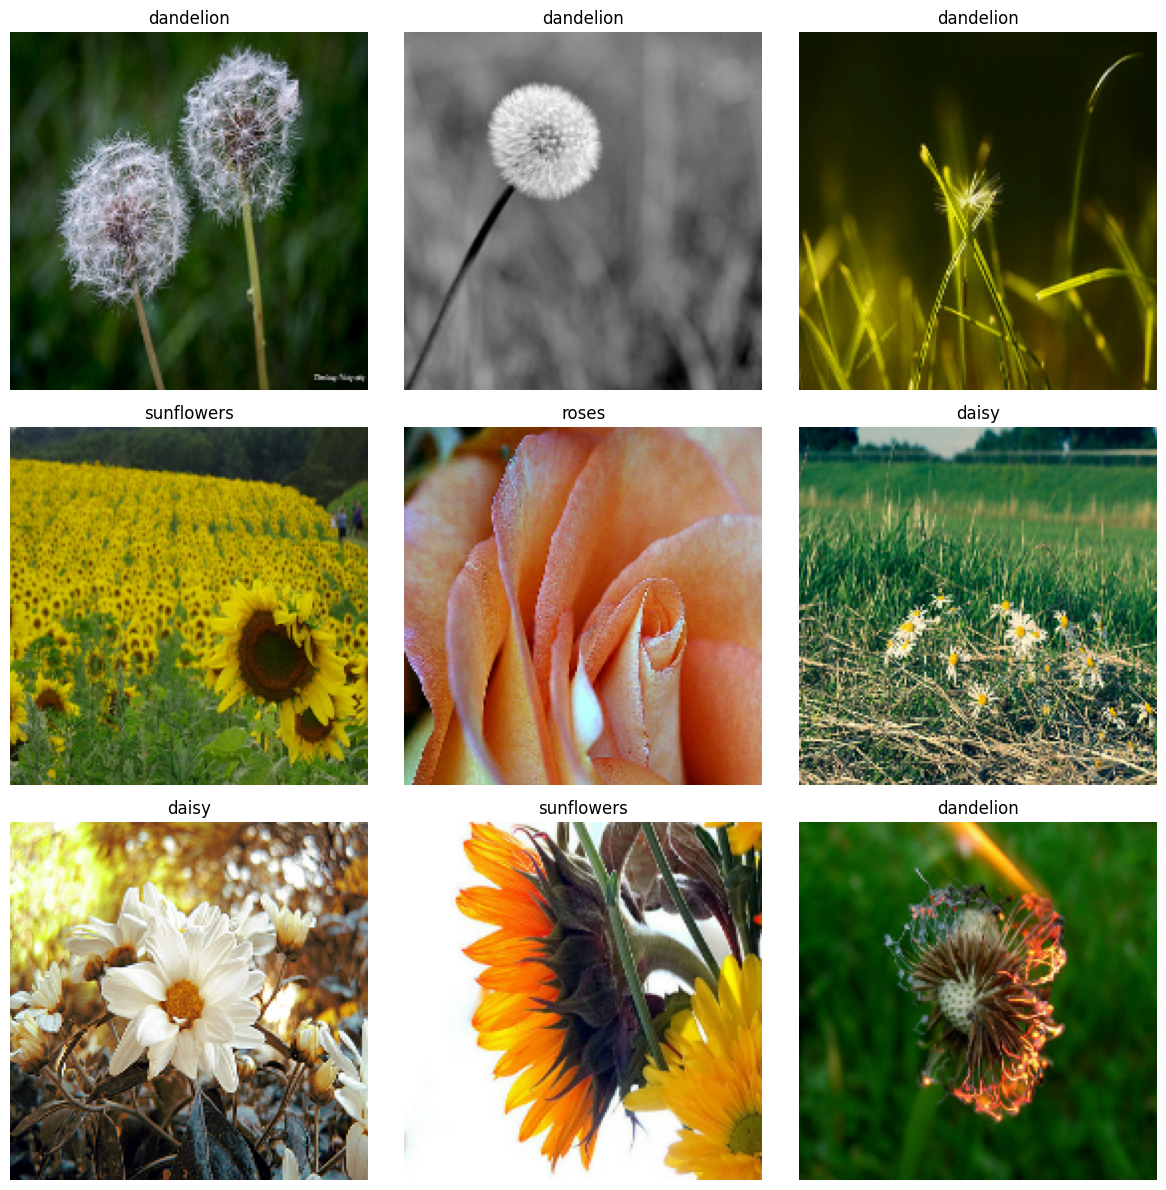

In [16]:
# Retrieve class names from the dataset
class_names = train_set.class_names

print("Flower Classes:")
print(class_names)

# Display sample images
plt.figure(figsize=(12, 12))

for images, labels in train_set.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

This code takes the first batch of training images, displays the first 9 images in a 3×3 grid, and shows the correct flower name above each image so you can verify that the dataset has been loaded and labeled correctly.

## Normalize Images and Optimize the Data Pipeline

In [19]:
# Normalize pixel values
rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_set = train_set.map(lambda img, label: (rescale(img), label))
validation_set = validation_set.map(lambda img, label: (rescale(img), label))

# Optimize data pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_set = train_set.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_set = validation_set.cache().prefetch(AUTOTUNE)

print("✅ Data ready!")

✅ Data ready!
